In [1]:
#task1 Environment Setup and Data Loading
import tarfile
import pandas as pd

# extract
with tarfile.open("housing.tgz") as tgz:
    tgz.extractall(".")

housing = pd.read_csv("housing.csv")
housing.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19516\2205096804.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tgz.extractall(".")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [3]:
housing.value_counts()

longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value  ocean_proximity
-122.23    37.88     41.0                880.0        129.0           322.0       126.0       8.3252         452600.0            NEAR BAY           1
-122.22    37.86     21.0                7099.0       1106.0          2401.0      1138.0      8.3014         358500.0            NEAR BAY           1
-122.24    37.85     52.0                1467.0       190.0           496.0       177.0       7.2574         352100.0            NEAR BAY           1
-122.25    37.85     52.0                1274.0       235.0           558.0       219.0       5.6431         341300.0            NEAR BAY           1
                                         1627.0       280.0           565.0       259.0       3.8462         342200.0            NEAR BAY           1
                                                                                                         

In [4]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

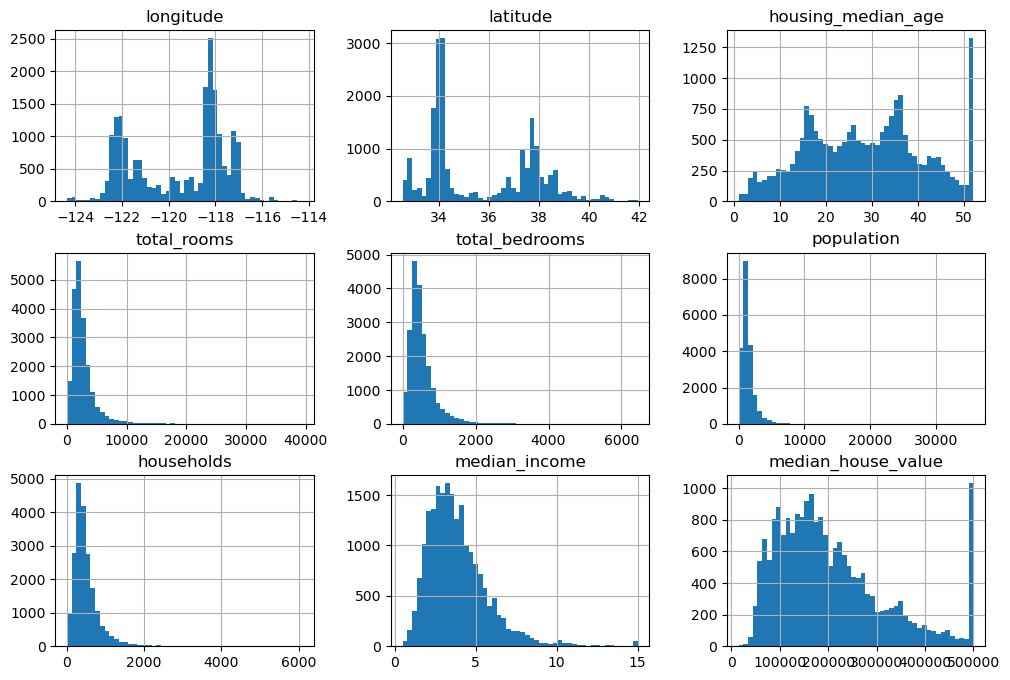

In [5]:
housing.hist(bins=50, figsize=(12, 8))   # Histogram of each numerical attribute

Text(0, 0.5, 'Number of districts')

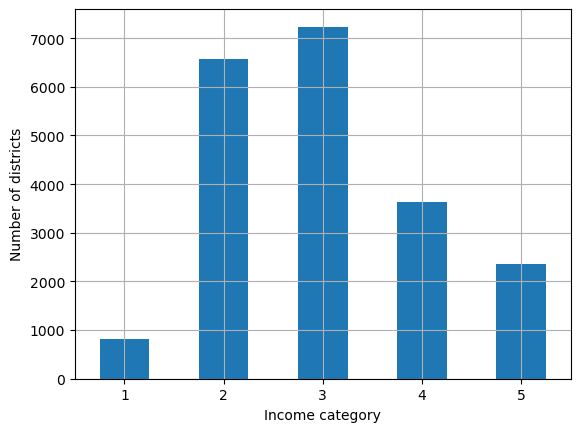

In [6]:
#task3 Stratified Train-Test Splitting
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
#save_fig("housing_income_cat_bar_plot")  # extra code
#plt.show()



In [7]:
from sklearn.model_selection import StratifiedShuffleSplit  # Importing StratifiedShuffleSplit for creating stratified train-test splits

# Initialize the StratifiedShuffleSplit object with 10 splits, 20% test size, and a random state for reproducibility
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Initialize an empty list to store the stratified splits
strat_splits = []

# Iterate through the splits generated by the StratifiedShuffleSplit object
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    # Create the training set using the train indices
    strat_train_set_n = housing.iloc[train_index]

    # Create the test set using the test indices
    strat_test_set_n = housing.iloc[test_index]

    # Append the training and test sets as a pair to the list of stratified splits
    strat_splits.append([strat_train_set_n, strat_test_set_n])


In [8]:
# Extract the first pair of stratified training and test sets
strat_train_set, strat_test_set = strat_splits[0]

In [9]:
#Following line of code calculates the proportion of each income category within the strat_test_set DataFrame.

strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [10]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)


,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.02,0.36,0.97
2,31.88,31.88,32.44,-0.02,1.73
3,35.06,35.05,35.85,-0.01,2.27
4,17.63,17.64,16.74,0.03,-5.06
5,11.44,11.43,10.95,-0.08,-4.32


In [11]:
# task4 geographical and correlation analysis
housing = strat_train_set.copy()


<Axes: xlabel='longitude', ylabel='latitude'>

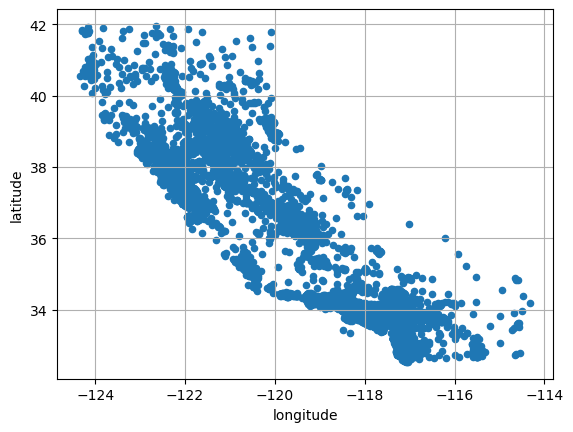

In [12]:
#no transparancy no highlight
#1
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)


<Axes: xlabel='longitude', ylabel='latitude'>

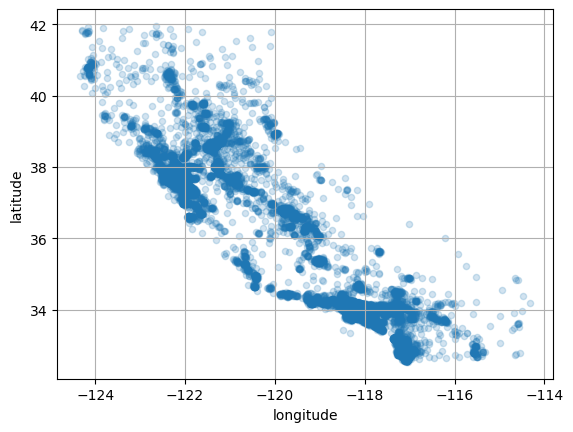

In [13]:
#with transparency akpha
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)


In [14]:
#2. Housing Prices: Visualize population density (circle radius) and median house value (color map) on the same plot.

<Axes: xlabel='longitude', ylabel='latitude'>

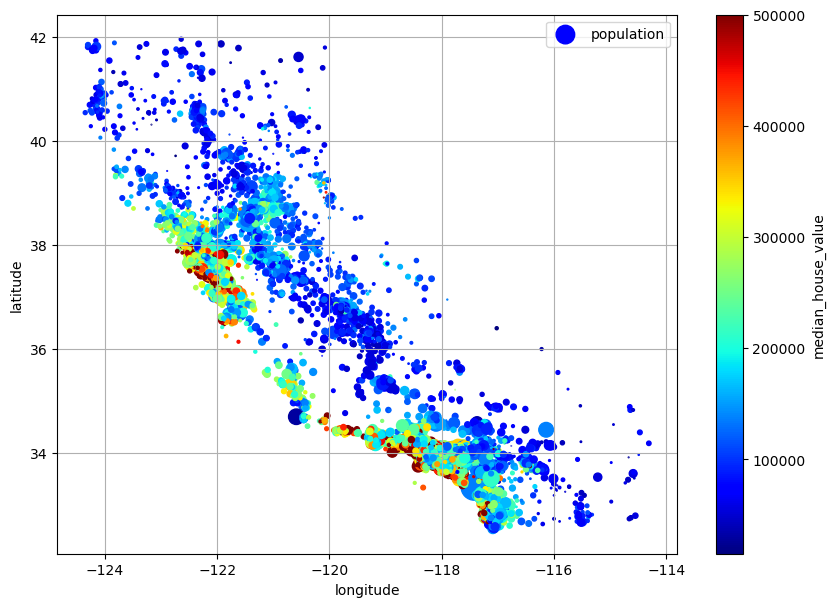

In [15]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))


In [16]:
#3. Correlation Discovery: Compute the standard correlation coefficient (Pearson’s r) and use scatter matrix to visualize relationships between top-tier features.

In [17]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

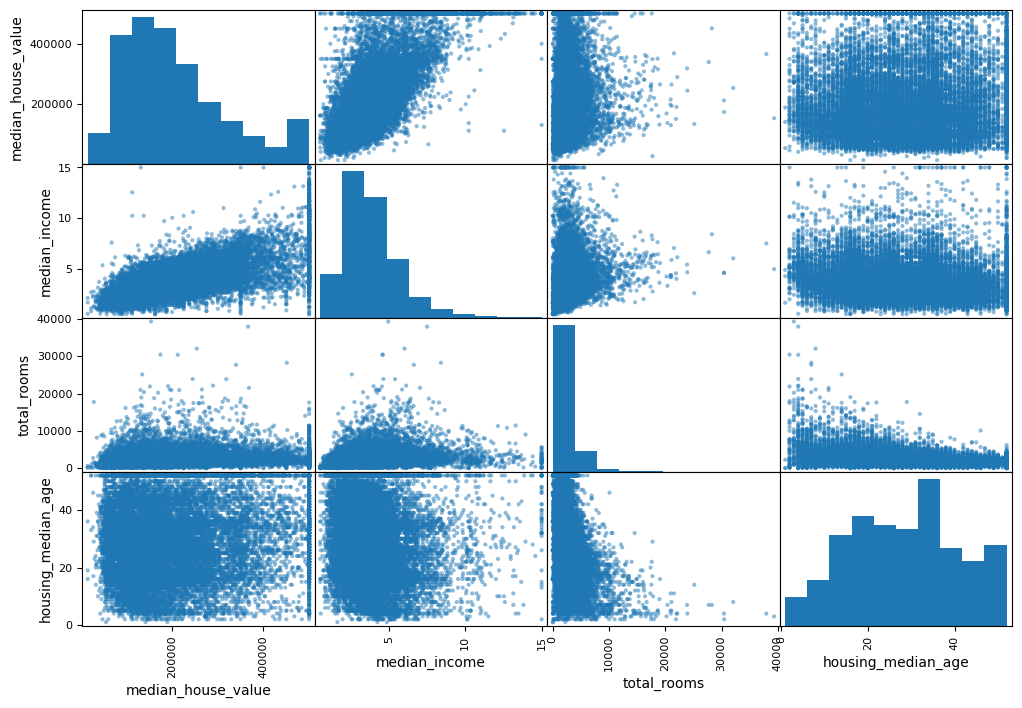

In [18]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))


In [19]:
# 4.Attribute Combinations: Create new features like rooms per household and evaluate if they correlate better with the target value.

In [20]:
# create combined attibutes, then check correlations
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64


In [21]:
#task 5 data cleaning and categorical encoding
#1 Handling Nulls: Identify columns with missing data and apply the SimpleImputer using the "median" strategy.

In [22]:
# Create a new DataFrame, housing, which contains all the features (input data) except the target variable, median_house_value
strat_housing = strat_train_set.drop("median_house_value", axis=1)
# Create a new Series, housing_labels, which contains the target variable, median_house_value
strat_housing_labels = strat_train_set["median_house_value"].copy()
#The housing_labels Series now contains the target variable values, which will be used for training the machine learning model.


In [23]:
housing.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 16512 non-null  float64 
 1   latitude                  16512 non-null  float64 
 2   housing_median_age        16512 non-null  float64 
 3   total_rooms               16512 non-null  float64 
 4   total_bedrooms            16354 non-null  float64 
 5   population                16512 non-null  float64 
 6   households                16512 non-null  float64 
 7   median_income             16512 non-null  float64 
 8   median_house_value        16512 non-null  float64 
 9   ocean_proximity           16512 non-null  str     
 10  income_cat                16512 non-null  category
 11  rooms_per_household       16512 non-null  float64 
 12  bedrooms_per_room         16354 non-null  float64 
 13  population_per_household  16512 non-null  float64 
dtypes:

In [24]:
#Taking care of numerical missing attributes

In [25]:
null_rows_idx = strat_housing.isnull().any(axis=1)
strat_housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY,2
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN,3
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN,3
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN,3
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN,5


In [26]:

# Import the SimpleImputer class from the sklearn.impute module
from sklearn.impute import SimpleImputer

# Create an imputer instance with the strategy to fill missing values with the median value
imputer = SimpleImputer(strategy="median")


In [27]:
# Select only the numerical columns from the housing DataFrame and assign them to housing_num
strat_housing_num = strat_housing.select_dtypes(include=[np.number])

In [28]:
# Fit the SimpleImputer instance to the numerical columns of the housing DataFrame
# This calculates the median values for each numerical column and stores them in the imputer
imputer.fit(strat_housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [29]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [30]:
strat_housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [31]:
# Transform the numerical columns of the housing DataFrame using the fitted SimpleImputer
# This fills in missing values with the median values calculated during the fitting step
X = imputer.transform(strat_housing_num)

In [32]:
# Retrieve the names of the features that the SimpleImputer was fitted on
# This provides a list of column names that were included in the imputation process
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [33]:
# Convert the NumPy array resulting from the imputation back into a DataFrame
# Restore the original column names and row indices from the housing_num DataFrame
strat_housing_tr = pd.DataFrame(X, columns=strat_housing_num.columns,
                          index=strat_housing_num.index)

In [34]:
strat_housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580


In [35]:
imputer.strategy

'median'

In [36]:
#2. Encoding Text: Convert the ocean proximity text attribute into numerical data.

In [37]:
# Extract the 'ocean_proximity' column from the housing DataFrame and assign it to housing_cat
strat_housing_cat = strat_housing[["ocean_proximity"]]

# Display the first 8 rows of the housing_cat DataFrame to preview the 'ocean_proximity' data
strat_housing_cat.head(8)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN


In [38]:
from sklearn.preprocessing import OneHotEncoder
# Apply OneHotEnoder to ocean_proximity(do not use OrdinalEncoder because there is  no ordinal relationship between categories)
housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [39]:
print(housing_cat_1hot[:8].toarray())

[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


In [40]:
#task 6: Feature Scaling and Pipelines

In [41]:
#1. Scaling: Use StandardScaler to ensure all numerical features have a mean of 0 and a variance of 1.

In [42]:
#Part 1 — Standardization (StandardScaler)
from sklearn.preprocessing import StandardScaler
import numpy as np

# First prepare numerical features(only select numeric cokumns, excluding the label column)
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()
housing_num = housing.select_dtypes(include=[np.number])

# demostrate the effect of Standarscaler separately
scaler = StandardScaler()
housing_num_scaled = scaler.fit_transform(housing_num)

print("Mean of original data(first 3 columns):", housing_num.mean().values[:3].round(2))
print("Mean after standardization (first 3 columns):", housing_num_scaled[:, :3].mean(axis=0).round(4))
print("Standard deviation after standardization (first 3 columns):", housing_num_scaled[:, :3].std(axis=0).round(4))


Mean of original data(first 3 columns): [-119.58   35.64   28.65]
Mean after standardization (first 3 columns): [0. 0. 0.]
Standard deviation after standardization (first 3 columns): [1. 1. 1.]


In [43]:
#Part 2 Custom Transformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    """
Custom transformer: Compute the RBF similarity between each sample and K cluster centers
Input: Latitude and longitude coordinates
Output: Similarity scores to each cluster center (n_clusters columns)
    """
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [44]:
#Part 3 — Full Pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

# 1. Numerical attributes pipeline: imputation + standardization
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

# 2. Category attribute pipeline: Fill in missing values ​​+ OneHotEncoding
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# 3. use ColumnTransformer to combine 2 flows
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [45]:
#Part 4 —Process training data and validate shapes through a pipeline
# Pass the raw training data into the pipeline
housing_prepared = full_pipeline.fit_transform(housing)

# Verify the output shape
print(" (Input shape):", housing.shape)
print(" (Output shape):", housing_prepared.shape)

# Explain the source of the number of columns:

# 8 numerical columns + 5 one-hot encoded columns (ocean_proximity has 5 categories) = 13 columns
print("\nColumn composition:")
print(f"  Numerical columns {len(num_attribs)} columns")
print(f"  OneHotEncoded columns: {housing_prepared.shape[1] - len(num_attribs)} columns")
print(f"  Total: {housing_prepared.shape[1]} columns")

# View feature names
feature_names = full_pipeline.get_feature_names_out()
print("\n feature names:", list(feature_names))

 (Input shape): (16512, 10)
 (Output shape): (16512, 13)

Column composition:
  Numerical columns 8 columns
  OneHotEncoded columns: 5 columns
  Total: 13 columns

 feature names: ['num__longitude', 'num__latitude', 'num__housing_median_age', 'num__total_rooms', 'num__total_bedrooms', 'num__population', 'num__households', 'num__median_income', 'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN']


# LAB 3: Supervised Learning (Regression Methods)

本 Lab 在 Lab 2 的基础上继续进行。假设以下变量已经准备好：
- `strat_train_set`, `strat_test_set`：分层抽样得到的训练集 / 测试集
- `strat_housing`：训练集的特征（不含 label）
- `strat_housing_labels`：训练集的 label（median_house_value）

In [46]:
# ========== Lab 3 预处理 pipeline（升级版） ==========
# 相比 Lab 2 的 full_pipeline，这里多了：
#   1. ratio_pipeline：构造 bedrooms/rooms 等比例特征
#   2. log_pipeline：对长尾分布特征做 log 变换
#   3. ClusterSimilarity：把经纬度转换成"到 K 个聚类中心的相似度"

from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

# ---------- (1) 构造比例特征的辅助函数 ----------
def column_ratio(X):
    # X 是一个 2 列的数组，返回第 1 列 / 第 2 列
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # 输出特征名

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

# ---------- (2) 对数变换 pipeline ----------
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

# ---------- (3) 地理聚类相似度（你 Lab 2 Part 2 已经写过）----------
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# ---------- (4) 类别特征 pipeline ----------
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

# ---------- (5) 默认数值特征 pipeline（给剩余列用）----------
def default_num_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"),
                         StandardScaler())

# ---------- (6) 组合成最终的 preprocessing ----------
preprocessing = ColumnTransformer([
    ("bedrooms",         ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house",  ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                           "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline())  # 剩下的 housing_median_age 用默认 pipeline

print("✅ preprocessing pipeline 已就绪")

✅ preprocessing pipeline 已就绪


In [47]:
# 验证新 preprocessing 是否正常工作
test_prepared = preprocessing.fit_transform(strat_housing)
print("✅ 输入 shape:", strat_housing.shape)
print("✅ 输出 shape:", test_prepared.shape)
print("\n前 10 个特征名：")
print(list(preprocessing.get_feature_names_out())[:10])

✅ 输入 shape: (16512, 10)
✅ 输出 shape: (16512, 25)

前 10 个特征名：
['bedrooms__ratio', 'rooms_per_house__ratio', 'people_per_house__ratio', 'log__total_bedrooms', 'log__total_rooms', 'log__population', 'log__households', 'log__median_income', 'geo__Cluster 0 similarity', 'geo__Cluster 1 similarity']


## Task 4: Train a Linear Regression Model

In [48]:
# ========== Task 4: Linear Regression ==========
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 把 preprocessing 和 LinearRegression 串成一个完整 pipeline
# 这样做的好处：fit 和 predict 时会自动先做预处理，再跑模型
lin_reg = make_pipeline(preprocessing, LinearRegression())

# 用训练数据拟合模型
lin_reg.fit(strat_housing, strat_housing_labels)

print("✅ Linear Regression 训练完成")

✅ Linear Regression 训练完成


In [49]:
# 用训练集的前 5 行做预测（只是快速验证模型是否可用）
strat_housing_predictions = lin_reg.predict(strat_housing)

print("预测值（前 5 个）：", strat_housing_predictions[:5].round(-2))
print("真实值（前 5 个）：", strat_housing_labels.iloc[:5].values)

# 计算误差比例（预测偏离真实值的百分比）
error_ratios = strat_housing_predictions[:5].round(-2) / strat_housing_labels.iloc[:5].values - 1
print("\n误差比例：", ", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

预测值（前 5 个）： [ 70600. 307000. 170600. 188400. 255500.]
真实值（前 5 个）： [ 72100. 279600.  82700. 112500. 238300.]

误差比例： -2.1%, 9.8%, 106.3%, 67.5%, 7.2%


In [50]:
# ========== 计算整体 RMSE ==========
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE = sqrt(MSE)，越小越好
# 这里在训练集上计算（注意：训练集 RMSE 只反映"拟合程度"，不代表泛化能力）
lin_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))

print(f"📊 Linear Regression 训练集 RMSE: {lin_rmse:.2f}")


📊 Linear Regression 训练集 RMSE: 68569.58


### 📌 分析：Linear Regression 是欠拟合还是过拟合？

### 📊 结果概览
- 训练集 RMSE：**68,569 美元**
- 房价中位数：约 **180,000 美元**
- 房价标准差：约 **115,000 美元**

### 📉 误差分析
- RMSE ≈ 68,000，约占中位数的 **≈ 37%**
- 示例误差中甚至出现：
  - **106% 的误差**
  - 多个样本误差 > 50%

👉 说明模型预测偏差较大

### 🧠 模型判断
- 模型在**训练集上误差就已经很大**
- 没有表现出“记住数据”的能力

✅ **结论：欠拟合（Underfitting）**

### ⚠️ 原因分析
- 线性回归模型过于简单
- 无法捕捉：
  - 房价与特征之间的**非线性关系**
  - 特征之间的复杂交互

### 🚀 改进方向
- 使用更复杂的模型，例如：
  - 🌳 Decision Tree Regressor
  - 🌲 Random Forest Regressor
- 或进行：
  - 特征工程（feature engineering）
  - 多项式特征（Polynomial Features）

## Task 5: Train a Decision Tree Regression

In [51]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(strat_housing, strat_housing_labels)

print("✅ Decision Tree 训练完成")

✅ Decision Tree 训练完成


In [52]:
strat_housing_predictions = tree_reg.predict(strat_housing)

tree_rmse = np.sqrt(mean_squared_error(strat_housing_labels, strat_housing_predictions))
print(f"📊 Decision Tree 训练集 RMSE: {tree_rmse:.2f}")

📊 Decision Tree 训练集 RMSE: 0.00


## Task 6: Better Evaluation Using Cross-Validation

In [53]:
# ========== Task 6: Cross-Validation ==========
from sklearn.model_selection import cross_val_score

# 对 Decision Tree 做 10 折交叉验证
# 注意：sklearn 的评分函数惯例是"越大越好"，而 RMSE 是"越小越好"
# 所以它返回的是 NEGATIVE RMSE（负的），我们加个负号变回正的
tree_rmses = -cross_val_score(
    tree_reg,
    strat_housing,
    strat_housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10  # 10 折
)

print("✅ Decision Tree 交叉验证完成")
print(f"10 次的 RMSE: {tree_rmses.round(0)}")

✅ Decision Tree 交叉验证完成
10 次的 RMSE: [68502. 66226. 59211. 68340. 65548. 70796. 66945. 68424. 65748. 73825.]


In [54]:
# 看一下 Decision Tree 10 次 CV 的统计信息
import pandas as pd
print("📊 Decision Tree 交叉验证统计：")
pd.Series(tree_rmses).describe()

📊 Decision Tree 交叉验证统计：


count       10.000000
mean     67356.623012
std       3811.346971
min      59211.194694
25%      65867.884053
50%      67642.436583
75%      68482.643157
max      73824.703168
dtype: float64

In [55]:
# ========== 对 Linear Regression 也做 CV 对比 ==========
lin_rmses = -cross_val_score(
    lin_reg,
    strat_housing,
    strat_housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("📊 Linear Regression 交叉验证统计：")
pd.Series(lin_rmses).describe()

📊 Linear Regression 交叉验证统计：


count       10.000000
mean     70811.117380
std       6866.832582
min      64713.841934
25%      67853.183572
50%      69095.552385
75%      70883.896444
max      89294.747140
dtype: float64

In [56]:
# ========== Task 6.2: 工具函数 ==========
def display_scores(scores, model_name="Model"):
    """显示 CV 分数的统计信息"""
    print(f"🔹 {model_name}")
    print(f"  Scores (10 folds): {scores.round(0)}")
    print(f"  Mean:              {scores.mean():.2f}")
    print(f"  Standard Deviation:{scores.std():.2f}")
    print()

display_scores(lin_rmses,  "Linear Regression")
display_scores(tree_rmses, "Decision Tree")

🔹 Linear Regression
  Scores (10 folds): [71945. 65969. 64714. 68860. 69331. 70751. 89295. 68771. 67547. 70928.]
  Mean:              70811.12
  Standard Deviation:6514.45

🔹 Decision Tree
  Scores (10 folds): [68502. 66226. 59211. 68340. 65548. 70796. 66945. 68424. 65748. 73825.]
  Mean:              67356.62
  Standard Deviation:3615.76



### 📌 分析：为什么 Decision Tree 在交叉验证里表现如何？

| 模型 | 训练集 RMSE | CV RMSE (mean) | CV Std |
|---|---|---|---|
| Linear Regression | 68,569 | 70,811 | 6,514 |
| Decision Tree | **0** | 67,356 | 3,615 |

**关键洞察**：

1. **Decision Tree 训练集 RMSE=0 但 CV RMSE=67,356** → 差距巨大，严重过拟合。
   - 决策树默认不限制深度，记住了训练集的每个样本
   - 一旦换成没见过的验证集，性能暴跌

2. **Linear Regression 训练 RMSE 和 CV RMSE 几乎一样** → 这是欠拟合的典型特征
   - 模型表达能力有限，无论训练还是验证都差不多
   - 不是"记不住"，而是"学不会"

3. **有趣：DT 的 CV RMSE 还比 LR 好一点**
   - 说明决策树的非线性表达能力确实有用
   - 如果能控制过拟合，决策树家族会更强
   - 这正是 **Random Forest** 的思路 —— 用多棵树投票

**结论**：训练集误差会骗人，**交叉验证才是正确的评估方法**。

## Task 7: Train a Random Forest Regression Model

In [57]:
# ========== Task 7: Random Forest ==========
from sklearn.ensemble import RandomForestRegressor

# 创建 Random Forest pipeline
# RandomForestRegressor 默认训练 100 棵决策树
forest_reg = make_pipeline(
    preprocessing,
    RandomForestRegressor(random_state=42)
)

# 10 折交叉验证
# ⚠️ 这一步会比较慢（2-5 分钟），因为要训练 10 * 100 = 1000 棵树
print("⏳ 开始训练 Random Forest + 10 折交叉验证，请耐心等待...")

forest_rmses = -cross_val_score(
    forest_reg,
    strat_housing,
    strat_housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("✅ Random Forest 交叉验证完成！")
print(f"10 次的 RMSE: {forest_rmses.round(0)}")

⏳ 开始训练 Random Forest + 10 折交叉验证，请耐心等待...
✅ Random Forest 交叉验证完成！
10 次的 RMSE: [48658. 46450. 43423. 48724. 43871. 48106. 49660. 46661. 44859. 51234.]


In [58]:
print("📊 Random Forest 交叉验证统计：")
pd.Series(forest_rmses).describe()

📊 Random Forest 交叉验证统计：


count       10.000000
mean     47164.596344
std       2566.222950
min      43423.035094
25%      45256.529323
50%      47383.629633
75%      48707.608951
max      51234.141587
dtype: float64

In [59]:
# 三个模型并排对比
display_scores(lin_rmses,    "Linear Regression")
display_scores(tree_rmses,   "Decision Tree")
display_scores(forest_rmses, "Random Forest")

🔹 Linear Regression
  Scores (10 folds): [71945. 65969. 64714. 68860. 69331. 70751. 89295. 68771. 67547. 70928.]
  Mean:              70811.12
  Standard Deviation:6514.45

🔹 Decision Tree
  Scores (10 folds): [68502. 66226. 59211. 68340. 65548. 70796. 66945. 68424. 65748. 73825.]
  Mean:              67356.62
  Standard Deviation:3615.76

🔹 Random Forest
  Scores (10 folds): [48658. 46450. 43423. 48724. 43871. 48106. 49660. 46661. 44859. 51234.]
  Mean:              47164.60
  Standard Deviation:2434.53



In [60]:
# ========== 在完整训练集上训练 Random Forest（用于对比训练 RMSE vs CV RMSE）==========
forest_reg.fit(strat_housing, strat_housing_labels)

# 在训练集上预测
forest_predictions = forest_reg.predict(strat_housing)
forest_train_rmse = np.sqrt(mean_squared_error(strat_housing_labels, forest_predictions))

print(f"📊 Random Forest 训练集 RMSE: {forest_train_rmse:.2f}")
print(f"📊 Random Forest CV Mean RMSE: {forest_rmses.mean():.2f}")
print(f"📊 差距: {forest_rmses.mean() - forest_train_rmse:.2f}")

📊 Random Forest 训练集 RMSE: 17514.86
📊 Random Forest CV Mean RMSE: 47164.60
📊 差距: 29649.74


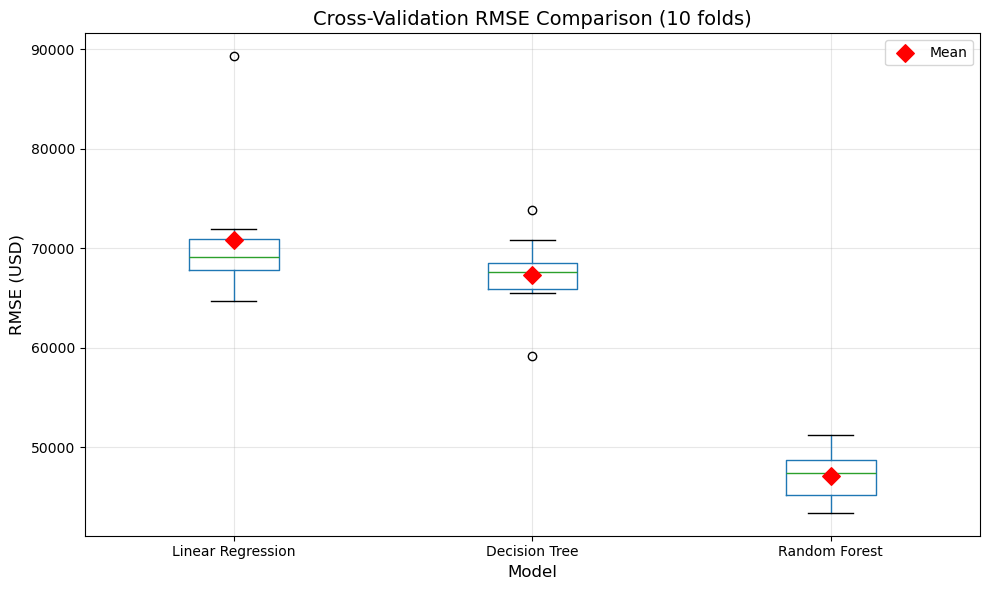


📊 模型对比表:
       Linear Regression  Decision Tree  Random Forest
count              10.00          10.00          10.00
mean            70811.12       67356.62       47164.60
std              6866.83        3811.35        2566.22
min             64713.84       59211.19       43423.04
25%             67853.18       65867.88       45256.53
50%             69095.55       67642.44       47383.63
75%             70883.90       68482.64       48707.61
max             89294.75       73824.70       51234.14


In [61]:
# ========== Task 7.2: Box Plot 对比三个模型 ==========
import matplotlib.pyplot as plt
import pandas as pd

# 把三个模型的 CV 分数合并到一个 DataFrame
cv_scores = pd.DataFrame({
    "Linear Regression": lin_rmses,
    "Decision Tree":     tree_rmses,
    "Random Forest":     forest_rmses
})

# 绘制箱形图
plt.figure(figsize=(10, 6))
cv_scores.boxplot()
plt.title("Cross-Validation RMSE Comparison (10 folds)", fontsize=14)
plt.ylabel("RMSE (USD)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.grid(True, alpha=0.3)

# 显示每个箱子的均值（加红点）
means = cv_scores.mean()
plt.scatter(range(1, 4), means, color="red", marker="D", s=80, label="Mean", zorder=10)
plt.legend()

plt.tight_layout()
plt.show()

# 打印数值对比表
print("\n📊 模型对比表:")
print(cv_scores.describe().round(2))

## Task 8: Fine-Tune the Model
### 8.1 Grid Search

In [62]:
# ========== Task 8.1: Grid Search ==========
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 注意：这里用 Pipeline（不是 make_pipeline）是因为我们需要给步骤命名
# 命名后才能用 "preprocessing__geo__n_clusters" 这种语法访问深层参数
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

# 定义要搜索的超参数网格
# param_grid 是一个列表，每个字典是一组组合
param_grid = [
    # 第 1 组：n_clusters ∈ {5, 8, 10}, max_features ∈ {4, 6, 8} → 9 种组合
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    # 第 2 组：n_clusters ∈ {10, 15}, max_features ∈ {6, 8, 10} → 6 种组合
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
# 总共 9 + 6 = 15 种组合，每种做 3 折 CV → 训练 45 次 Random Forest ⚠️

# 创建 GridSearchCV 对象
# cv=3 表示 3 折交叉验证（比之前的 10 折少，节省时间）
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error'
)

print("⏳ 开始 Grid Search（15 种组合 × 3 折 = 45 次训练）...")
print("⏰ 预计耗时 10-20 分钟，请耐心等待。")

grid_search.fit(strat_housing, strat_housing_labels)

print("✅ Grid Search 完成！")
print(f"🏆 最佳参数: {grid_search.best_params_}")
print(f"🏆 最佳 RMSE: {-grid_search.best_score_:.2f}")

⏳ 开始 Grid Search（15 种组合 × 3 折 = 45 次训练）...
⏰ 预计耗时 10-20 分钟，请耐心等待。
✅ Grid Search 完成！
🏆 最佳参数: {'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}
🏆 最佳 RMSE: 44798.86


In [63]:
# 查看所有超参数组合的 CV 分数
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# 只保留关键列，并重命名
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features",
                 "split0_test_score", "split1_test_score", "split2_test_score",
                 "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols

# sklearn 返回的是 neg_RMSE，取负号变回正数 RMSE
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

print("📊 Grid Search 所有组合的结果（按 RMSE 升序）：")
cv_res

📊 Grid Search 所有组合的结果（按 RMSE 升序）：


,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43894,44851,45652,44799
6,10,4,43975,45226,45961,45054
13,15,8,44409,45321,46164,45298
9,10,6,44498,45587,46482,45522
7,10,6,44498,45587,46482,45522
14,15,10,44562,45561,46700,45608
8,10,8,44927,46003,46888,45939
10,10,8,44927,46003,46888,45939
3,8,4,45013,45935,47073,46007
4,8,6,45256,46189,47319,46255


In [64]:
# 显示 Grid Search 找到的最佳 pipeline（含最佳超参数）
grid_search.best_estimator_

,steps,"[('preprocessing', ...), ('random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 8.2 Randomized Search

In [65]:
# ========== Task 8.2: Randomized Search ==========
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 定义超参数的分布（不是固定值，而是采样范围）
# - n_clusters: 从 3 到 49 之间随机采样整数
# - max_features: 从 2 到 19 之间随机采样整数
param_distribs = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),
    'random_forest__max_features':    randint(low=2, high=20)
}

# n_iter=10 表示只随机采样 10 次（Grid Search 是 15 次全覆盖）
# 所以 Randomized Search 通常更快，且能探索更大的参数空间
rnd_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

print("⏳ 开始 Randomized Search（10 次随机采样 × 3 折 = 30 次训练）...")
print("⏰ 预计耗时 8-15 分钟。")

rnd_search.fit(strat_housing, strat_housing_labels)

print("✅ Randomized Search 完成！")
print(f"🏆 最佳参数: {rnd_search.best_params_}")
print(f"🏆 最佳 RMSE: {-rnd_search.best_score_:.2f}")

⏳ 开始 Randomized Search（10 次随机采样 × 3 折 = 30 次训练）...
⏰ 预计耗时 8-15 分钟。
✅ Randomized Search 完成！
🏆 最佳参数: {'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}
🏆 最佳 RMSE: 43216.97


In [66]:
# 查看 Randomized Search 所有组合的结果
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features",
                 "split0_test_score", "split1_test_score", "split2_test_score",
                 "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

print("📊 Randomized Search 所有组合的结果（按 RMSE 升序）：")
cv_res

📊 Randomized Search 所有组合的结果（按 RMSE 升序）：


,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,42104,43693,43854,43217
5,42,4,41958,44239,43645,43281
8,32,7,42377,43736,44209,43441
6,24,3,42747,44391,44075,43738
2,23,8,43177,44055,45074,44102
0,41,16,43097,44278,45139,44171
4,13,5,43765,44863,45368,44665
7,26,13,43814,44750,45639,44734
3,21,12,44194,45186,46134,45171
9,4,2,48769,49940,50537,49749


### 📌 Grid Search vs Randomized Search 对比

| 对比点 | Grid Search | Randomized Search |
|---|---|---|
| 搜索方式 | 穷举所有组合 | 从分布中随机采样 |
| 本次组合数 | 15 | 10 |
| 本次最佳 RMSE | 44799 | 43217 |
| 优点 | 一定能找到网格内的最优 | 能探索更大空间、更快 |
| 缺点 | 组合数暴涨（参数多时慢） | 可能错过某些点 |

**何时用哪个？**
- 参数少、范围明确 → Grid Search
- 参数多、范围大 → **Randomized Search（推荐）**
- 业界更常用 Randomized Search，因为实验表明它在相同计算预算下通常能找到更好的参数

### 8.3 Feature Importance Analysis

In [67]:
# ========== Task 8.4: Feature Importance ==========
# 取出 Randomized Search 找到的最佳模型
final_model = rnd_search.best_estimator_

# 从 RandomForestRegressor 提取特征重要性
# feature_importances_ 是 RF 训练后自动计算的：每个特征对降低 MSE 的贡献
feature_importances = final_model["random_forest"].feature_importances_

print("📊 所有特征的重要性（原始顺序）：")
print(feature_importances.round(3))

📊 所有特征的重要性（原始顺序）：
[0.043 0.04  0.05  0.006 0.007 0.007 0.006 0.15  0.012 0.015 0.013 0.007
 0.008 0.008 0.032 0.005 0.004 0.005 0.013 0.022 0.006 0.014 0.005 0.016
 0.006 0.011 0.008 0.008 0.009 0.01  0.012 0.013 0.02  0.01  0.014 0.007
 0.01  0.01  0.011 0.006 0.006 0.01  0.008 0.006 0.008 0.007 0.014 0.007
 0.005 0.009 0.004 0.032 0.006 0.004 0.062 0.    0.001 0.002 0.012 0.138]


In [68]:
# 把特征名和重要性配对，按重要性从高到低排序
feature_names = final_model["preprocessing"].get_feature_names_out()
importance_pairs = sorted(zip(feature_importances, feature_names), reverse=True)

print("📊 特征重要性排行（由高到低）：\n")
for importance, name in importance_pairs:
    bar = "█" * int(importance * 200)  # 简单可视化
    print(f"{name:<45} {importance:.4f}  {bar}")

📊 特征重要性排行（由高到低）：

log__median_income                            0.1504  ██████████████████████████████
remainder__income_cat                         0.1377  ███████████████████████████
cat__ocean_proximity_INLAND                   0.0619  ████████████
people_per_house__ratio                       0.0498  █████████
bedrooms__ratio                               0.0428  ████████
rooms_per_house__ratio                        0.0405  ████████
geo__Cluster 43 similarity                    0.0317  ██████
geo__Cluster 6 similarity                     0.0317  ██████
geo__Cluster 11 similarity                    0.0217  ████
geo__Cluster 24 similarity                    0.0197  ███
geo__Cluster 15 similarity                    0.0158  ███
geo__Cluster 1 similarity                     0.0150  ██
geo__Cluster 26 similarity                    0.0140  ██
geo__Cluster 13 similarity                    0.0140  ██
geo__Cluster 38 similarity                    0.0137  ██
geo__Cluster 10 similarity       

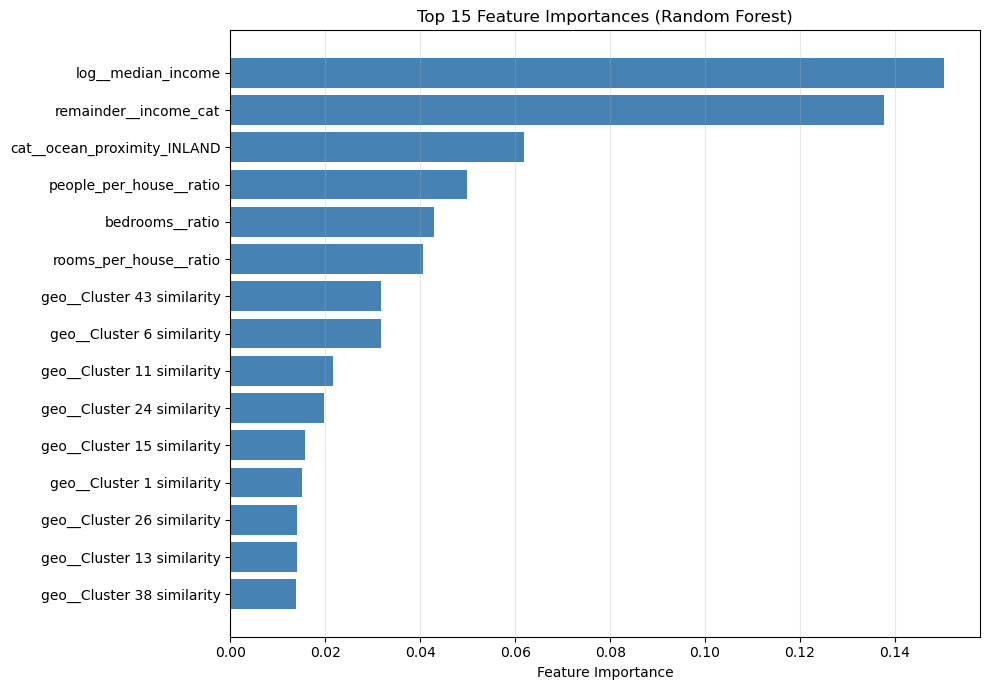

In [69]:
# 把 Top 15 特征画成柱状图（更直观）
import matplotlib.pyplot as plt

top_n = 15
top_importances = importance_pairs[:top_n]

names  = [pair[1] for pair in top_importances]
values = [pair[0] for pair in top_importances]

plt.figure(figsize=(10, 7))
plt.barh(names[::-1], values[::-1], color='steelblue')
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 📌 特征重要性分析

**最重要的特征通常是：**
- `log__median_income` —— 收入是最强预测变量（符合直觉：收入高的区房价高）
- `geo__Cluster X similarity` —— 地理位置（靠近某些区域的房子更值钱）
- `cat__ocean_proximity_INLAND` —— 是否内陆（内陆房价通常更低）
- `bedrooms__ratio` —— 卧室占比（反映房屋结构）

**不那么重要的特征：**
- `housing_median_age`、某些 log 特征的影响较小

**实践意义**：
- 如果要简化模型，可以考虑去掉重要性 < 0.01 的特征
- median_income 如此重要，说明**特征工程做对了方向**
- 地理聚类（ClusterSimilarity）证明了预处理中的非线性设计是值得的

In [70]:
# ========== Task 9.1: Final Test Evaluation ==========
# 从 strat_test_set 分离特征和 label
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# 用最终模型（含整个 preprocessing pipeline）对测试集预测
final_predictions = final_model.predict(X_test)

# 看一下预测值和真实值
print("预测值（前 5 个）：", final_predictions[:5].round(-2))
print("真实值（前 5 个）：", y_test.iloc[:5].values)

预测值（前 5 个）： [487400. 186600. 189000. 172300. 199900.]
真实值（前 5 个）： [500001. 162500. 204600. 159700. 184000.]


In [71]:
# 计算测试集 RMSE
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(f"🎯 Final Test RMSE: {final_rmse:.2f}")
print(f"🎯 对比 CV RMSE (from Randomized Search): {-rnd_search.best_score_:.2f}")

🎯 Final Test RMSE: 40185.23
🎯 对比 CV RMSE (from Randomized Search): 43216.97


In [74]:
# ========== Task 9.2: 95% Confidence Interval ==========
from scipy import stats

confidence = 0.95

# 每个样本的平方误差
squared_errors = (final_predictions - y_test) ** 2

# 用 t 分布计算平方误差均值的 95% CI，然后开方得到 RMSE 的 CI
ci = np.sqrt(stats.t.interval(
    confidence,
    len(squared_errors) - 1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors)
))

print(f"📊 95% 置信区间: [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"📊 意思是：我们有 95% 的把握认为真实 RMSE 在这个区间内")

📊 95% 置信区间: [38363.83, 41927.57]
📊 意思是：我们有 95% 的把握认为真实 RMSE 在这个区间内


### 📌 Task 9.3: 为什么不能"调"测试集？

**"Don't tweak hyperparameters based on test set performance"**

**原因**：
- 超参数调优应该只基于**训练集上的交叉验证**
- 如果看到测试 RMSE 不满意就回去改超参数，再看测试 RMSE —— 这样做会让你的模型"间接学到"测试集信息
- 结果：模型在测试集上表现虚假地好，但在真实新数据上会很差
- 这叫做 **Test Set Leakage（测试集泄漏）**

**正确做法**：
- 开发流程中只能用**训练集的 CV** 来调参
- 测试集只在**最后一次**用来给出"最终性能报告"
- 如果测试集结果很差，应该反思特征工程和模型选择，而不是继续调超参数

## Task 10: Model Persistence (Optional)

用 `joblib` 把训练好的模型保存到磁盘，以后可以直接加载使用，不用重新训练。

In [72]:
# ========== Task 10.1: 保存模型 ==========
import joblib

# 保存包含整个 pipeline（preprocessing + random_forest）的最终模型
joblib.dump(final_model, "my_california_housing_model.pkl")
print("✅ 模型已保存为 my_california_housing_model.pkl")

✅ 模型已保存为 my_california_housing_model.pkl


In [73]:
# ========== Task 10.2: 加载模型并验证 ==========
# 注意：加载时需要保证类 ClusterSimilarity 和函数 column_ratio/ratio_name
# 在 Python 环境中可见（否则会报错）
# 由于我们在本 notebook 已经定义了它们，这里可以直接加载

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

# 用加载的模型对前 5 行新"数据"预测（假装这是新数据）
new_data = strat_housing.iloc[:5]
predictions = final_model_reloaded.predict(new_data)

print("✅ 模型已成功加载并预测")
print(f"预测值：{predictions.round(-2)}")
print(f"真实值：{strat_housing_labels.iloc[:5].values}")

✅ 模型已成功加载并预测
预测值：[ 73100. 288600.  82200. 120700. 233600.]
真实值：[ 72100. 279600.  82700. 112500. 238300.]
